In [57]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from os import listdir
from os.path import isfile, join
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from utils import analysis_utils as au
import re
from tqdm import tqdm
import json 

In [46]:
# Extract all the datasets into a dictionary with the key as the name
data_path = "../../results/hidden_state_experiment"
regex = "eval_hidden_state_(.*).npy"
files = [f for f in listdir(data_path) if isfile(join(data_path, f))]
datasets = {}
for f in files:
    configName = re.search(regex, f).group(1)
    datasets[configName] = np.load(join(data_path, f))

In [47]:
# Compute the cosine similarities for the layer skipping approach
layer_wise_similarities = {}
layer_to_final_similarities = {}
full_model_hidden_states = datasets.pop("FM")
num_layers = full_model_hidden_states.shape[0]
num_tokens = full_model_hidden_states.shape[1]
for configName, skipping_model_hidden_states in tqdm(datasets):
    layer_wise_cosine_similarities = []
    layer_to_final_cosine_similarities = []
    for i in range(1, num_layers):
        layer_wise_cosine_similarities.append(au.cosine_similarity(full_model_hidden_states[i], skipping_model_hidden_states[i]))
        layer_to_final_cosine_similarities.append(au.cosine_similarity(full_model_hidden_states[-1], skipping_model_hidden_states[i]))
    layer_wise_similarities[configName] = layer_wise_cosine_similarities
    layer_to_final_similarities[configName] = layer_to_final_cosine_similarities

0it [00:00, ?it/s]


In [50]:
# Compute the cosine similarities for the early exitting approach
for ee_layer in tqdm(range(1, num_layers-1)):
    configName = f"B{ee_layer}" # Stands for execute Bottom X layers
    early_exitting_hidden_states = np.append(full_model_hidden_states[:ee_layer], [full_model_hidden_states[ee_layer]] * (num_layers - ee_layer), axis=0) # Repeat the last hidden state before EE
    layer_wise_cosine_similarities = []
    layer_to_final_cosine_similarities = []
    for i in range(1, num_layers):
        layer_wise_cosine_similarities.append(au.cosine_similarity(full_model_hidden_states[i], early_exitting_hidden_states[i]))
        layer_to_final_cosine_similarities.append(au.cosine_similarity(full_model_hidden_states[-1], early_exitting_hidden_states[i]))
    layer_wise_similarities[configName] = layer_wise_cosine_similarities
    layer_to_final_similarities[configName] = layer_to_final_cosine_similarities
    

100%|██████████| 12/12 [06:41<00:00, 33.49s/it]


In [75]:
# Save to json file
with open('layer_wise_similarities.json', 'w') as fout:
    json.dump(str(layer_wise_similarities), fout)

with open('layer_to_final_similarities.json', 'w') as fout:
    json.dump(str(layer_to_final_similarities), fout)

In [76]:
# Load from json file
with open('layer_wise_similarities.json', 'r') as fin:
    layer_wise_similarities = eval(json.load(fin))

with open('layer_to_final_similarities.json', 'r') as fin:
    layer_to_final_similarities = eval(json.load(fin))

Text(0.5, 1.0, 'Layer-wise cosine similarities with full model')

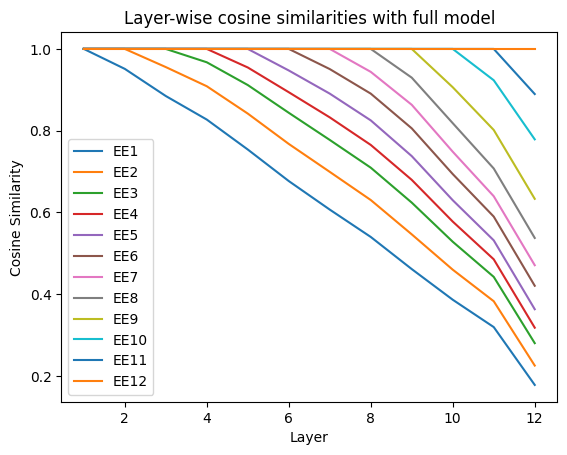

In [77]:
# Plot all the layer-wise cosine similarities
plt.figure()
for configName, similarities in layer_wise_similarities.items():
    plt.plot(range(1, num_layers), similarities, label=configName)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.title("Layer-wise cosine similarities with full model")

Text(0.5, 1.0, 'Layer to final cosine similarities with full model')

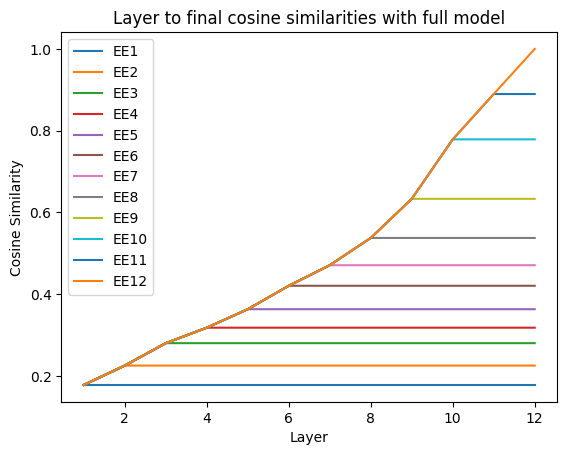

In [78]:
# Plot all the layer to final cosine similarities
plt.figure()
for configName, similarities in layer_to_final_similarities.items():
    plt.plot(range(1, num_layers), similarities, label=configName)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.title("Layer to final cosine similarities with full model")